# TAIFEX TXO options — full-history analysis

Explore the per-strike daily options data scraped from TAIFEX's `optDailyMarketSummary`. Every section is a distinct analytical angle.

## Sections
1. Load + parse — clean DataFrame with expiry type + underlying spot merged in
2. Overview stats — row counts, expiries, coverage over time
3. Aggregate volume & OI over time — big-picture liquidity growth
4. Put/call ratio — the classic sentiment indicator (volume PCR + OI PCR)
5. Term structure — front-month vs deferred OI share
6. Weekly vs monthly options mix — since weekly options were introduced (~2012)
7. Strike moneyness distribution — where does volume concentrate
8. ATM straddle premium — implied-vol proxy over time
9. Put skew — 25Δ put / 25Δ call price ratio (crash-fear proxy)
10. Signal sketches — how to fold these into `cta.Simulate`

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = [
    "Hiragino Sans GB", "Heiti TC", "Songti SC",
    "PingFang HK", "Arial Unicode MS", "DejaVu Sans",
]

import cta

CSV_PATH = "taifex_txo_daily.csv"
print(f"reading {CSV_PATH} ...")
df = pd.read_csv(CSV_PATH, dtype={"expiry": str}, parse_dates=["date"], low_memory=False)
print(f"loaded: {len(df):,} rows across {df.date.nunique():,} dates "
      f"({df.date.min().date()} → {df.date.max().date()})")

reading taifex_txo_daily.csv ...
loaded: 424,812 rows across 5,879 dates (2001-12-24 → 2025-12-05)


## 1. Parse expiries & merge underlying spot

The `expiry` column is like `202501` (monthly), `202501W1` (weekly-1), `202501F1` (final settlement — rare). Extract:
* `expiry_type` — 'monthly' vs 'weekly' vs 'other'
* `expiry_month` — the `YYYYMM` prefix, useful for aggregating by expiry cycle
* `underlying` — MXF close for that date (TAIEX proxy, since MXF is 1/4 of TX/TXO but tracks the same index)
* `moneyness` — `strike / underlying - 1` (0 = ATM, +5% = OTM call, −5% = OTM put)

In [2]:
# Expiry parsing
df["expiry_month"] = df["expiry"].str[:6]
df["expiry_type"] = np.where(df["expiry"].str.contains("W", na=False), "weekly",
                             np.where(df["expiry"].str.match(r"^\d{6}$").fillna(False),
                                      "monthly", "other"))
print("expiry_type counts:")
print(df["expiry_type"].value_counts())

# Underlying spot — MXF close, joined by date
ASSET = cta.load_asset("mtx", "1d")
spot = ASSET["close"].rename("underlying")
df = df.merge(spot, left_on="date", right_index=True, how="left")
df["moneyness"] = df["strike"] / df["underlying"] - 1
df["log_moneyness"] = np.log(df["strike"] / df["underlying"])

print(f"\nrows with spot merged: {df['underlying'].notna().sum():,} / {len(df):,}")
df.head(5)

expiry_type counts:
expiry_type
monthly    349724
weekly      70268
other        4820
Name: count, dtype: int64

rows with spot merged: 424,812 / 424,812


,date,market_code,side,expiry,strike,high,low,last,settlement,change,volume,oi,expiry_month,expiry_type,underlying,moneyness,log_moneyness
0,2001-12-24,0,call,200201,4900.0,370.0,180.0,301.0,301.0,-19.0,14.0,9.0,200201,monthly,5110.0,-0.041096,-0.041964
1,2001-12-24,0,call,200201,5000.0,275.0,218.0,275.0,275.0,17.0,7.0,4.0,200201,monthly,5110.0,-0.021526,-0.021761
2,2001-12-24,0,call,200201,5100.0,230.0,162.0,200.0,200.0,-5.0,131.0,116.0,200201,monthly,5110.0,-0.001957,-0.001959
3,2001-12-24,0,call,200201,5200.0,180.0,115.0,151.0,151.0,-8.0,298.0,122.0,200201,monthly,5110.0,0.017613,0.017459
4,2001-12-24,0,call,200201,5300.0,130.0,99.0,110.0,110.0,-11.0,374.0,159.0,200201,monthly,5110.0,0.037182,0.036507


## 2. Overview — date coverage, rows-per-day, expiry mix by year

Establishes when the various contract types launched (weeklies came online ~2012).

annual row counts by expiry_type:
expiry_type  monthly  other  weekly
year                               
2001             148      0       0
2002           11544      0       0
2003           11228      0       0
2004           12844      0       0
2005           12776      0       0
2006           13108      0       0
2007           13894      0       0
2008           13838      0       0
2009           13410      0       0
2010           14554      0       0
2011           18118      0       0
2012           25440      0     540
2013           14640      0    4580
2014           14820      0    4560
2015           14626      0    4532
2016           14460      0    4560
2017           14538      0    4440
2018           14700      0    4550
2019           14520      0    4500
2020           14698      0    4486
2021           14640      0    4520
2022           14760      0    5180
2023           14340      0    7920
2024           14520      0    8260
2025           13560   4820   

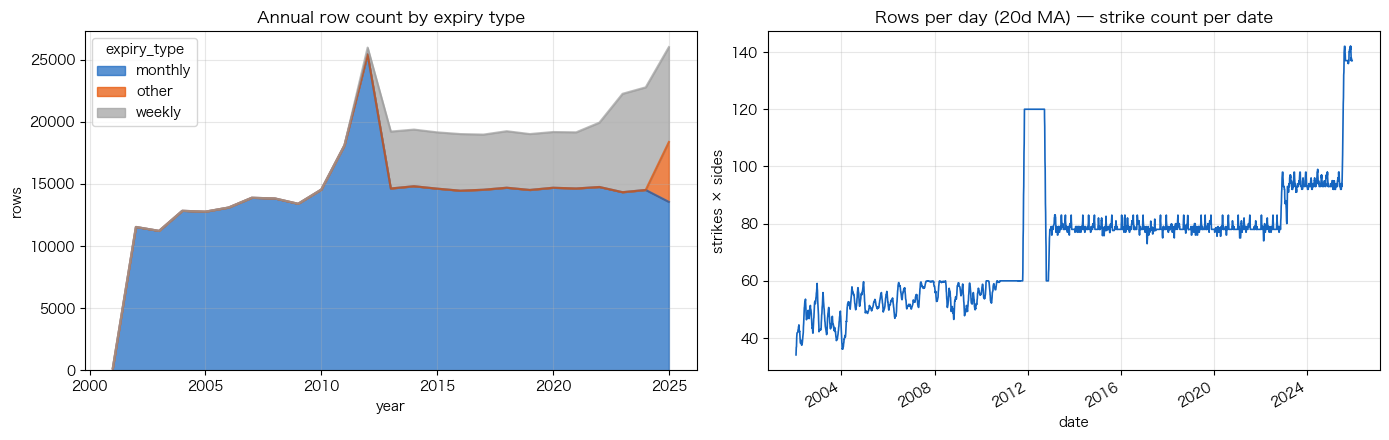

In [3]:
yearly = (df.assign(year=df["date"].dt.year)
           .groupby(["year", "expiry_type"]).size()
           .unstack(fill_value=0))
print("annual row counts by expiry_type:")
print(yearly.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

yearly.plot(kind="area", stacked=True, ax=axes[0], alpha=0.7,
            color=["#1565c0", "#e65100", "#9e9e9e"])
axes[0].set_title("Annual row count by expiry type")
axes[0].set_ylabel("rows"); axes[0].grid(alpha=0.3)

rpd = df.groupby("date").size()
rpd.rolling(20).mean().plot(ax=axes[1], color="#1565c0", lw=1.2)
axes[1].set_title("Rows per day (20d MA) — strike count per date")
axes[1].set_ylabel("strikes × sides"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 3. Aggregate volume & OI over time — market growth

Sum volume and OI across all strikes and expiries per date. This is total TXO liquidity in contracts.

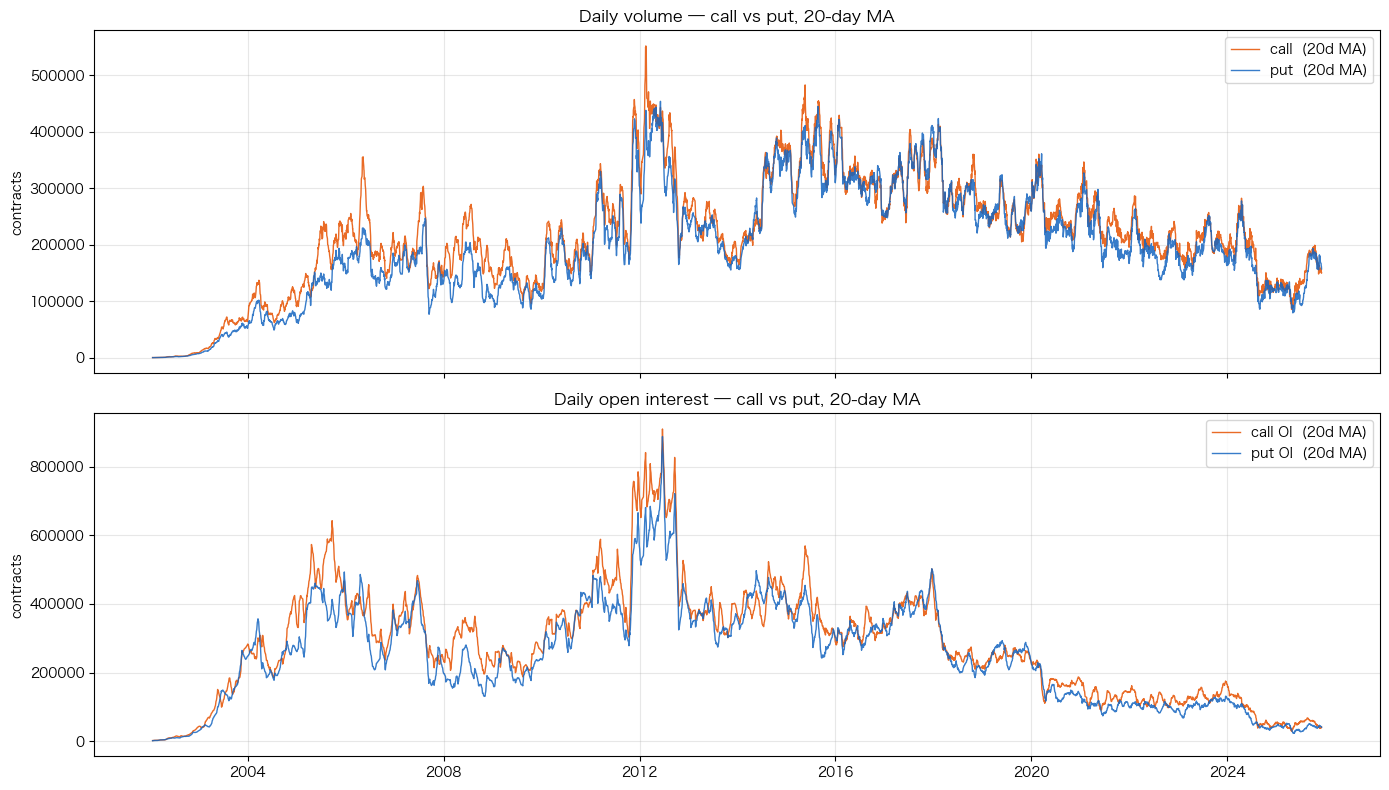


recent totals:
            volume_call  volume_put  oi_call   oi_put  volume_total  oi_total
date                                                                         
2025-12-01      19239.0     66453.0  19874.0  28618.0       85692.0   48492.0
2025-12-02      90056.0     90590.0  41317.0  31638.0      180646.0   72955.0
2025-12-03     279273.0    251259.0  76281.0  46778.0      530532.0  123059.0
2025-12-04      91873.0     67747.0  31215.0  18053.0      159620.0   49268.0
2025-12-05     244291.0    175520.0  69156.0  36575.0      419811.0  105731.0


In [4]:
agg = df.groupby(["date", "side"])[["volume", "oi"]].sum().unstack("side").fillna(0)
agg.columns = ["_".join(c) for c in agg.columns]     # 'volume_call', 'oi_put', ...
agg["volume_total"] = agg["volume_call"] + agg["volume_put"]
agg["oi_total"]     = agg["oi_call"]     + agg["oi_put"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for c, color, lbl in [("volume_call", "#e65100", "call"),
                      ("volume_put",  "#1565c0", "put")]:
    axes[0].plot(agg.index, agg[c].rolling(20).mean(),
                 color=color, lw=1.0, label=f"{lbl}  (20d MA)", alpha=0.85)
axes[0].set_title("Daily volume — call vs put, 20-day MA")
axes[0].set_ylabel("contracts"); axes[0].legend(); axes[0].grid(alpha=0.3)

for c, color, lbl in [("oi_call", "#e65100", "call OI"),
                      ("oi_put",  "#1565c0", "put OI")]:
    axes[1].plot(agg.index, agg[c].rolling(20).mean(),
                 color=color, lw=1.0, label=f"{lbl}  (20d MA)", alpha=0.85)
axes[1].set_title("Daily open interest — call vs put, 20-day MA")
axes[1].set_ylabel("contracts"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\nrecent totals:")
print(agg.tail(5).round(0))

## 4. Put/call ratio — sentiment indicator

* **Volume PCR** = `put volume / call volume` — daily positioning flow. High PCR = fear (people buying puts to hedge / speculate on downside).
* **OI PCR** = `put OI / call OI` — accumulated positioning. Slower-moving, structural.

PCR is a **contrarian** indicator in most literature — extremes typically mean-revert. High PCR → likely bounce; low PCR (complacency) → risk of decline.

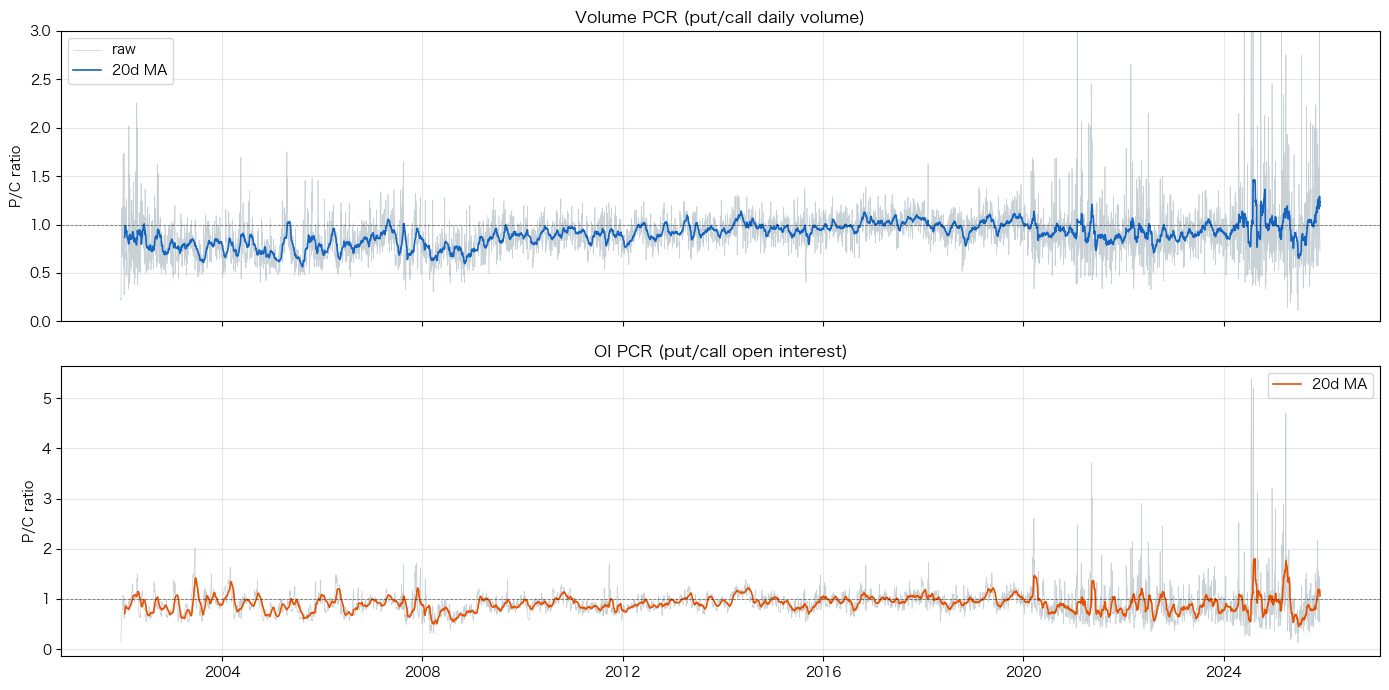

Recent PCR percentiles (last 252 days):
  vol PCR: count    252.00
mean       0.98
std        0.46
min        0.11
10%        0.57
50%        0.90
90%        1.43
max        3.45
  oi  PCR: count    252.00
mean       0.90
std        0.54
min        0.12
10%        0.43
50%        0.78
90%        1.51
max        4.71


In [5]:
agg["pcr_vol"] = agg["volume_put"] / agg["volume_call"].replace(0, np.nan)
agg["pcr_oi"]  = agg["oi_put"]     / agg["oi_call"].replace(0, np.nan)

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(agg.index, agg["pcr_vol"], color="#90a4ae", lw=0.5, alpha=0.5, label="raw")
ax[0].plot(agg.index, agg["pcr_vol"].rolling(20).mean(),
           color="#1565c0", lw=1.2, label="20d MA")
ax[0].axhline(1.0, color="black", lw=0.6, ls="--", alpha=0.5)
ax[0].set_title("Volume PCR (put/call daily volume)")
ax[0].set_ylabel("P/C ratio"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_ylim(0, 3)

ax[1].plot(agg.index, agg["pcr_oi"], color="#90a4ae", lw=0.5, alpha=0.5)
ax[1].plot(agg.index, agg["pcr_oi"].rolling(20).mean(),
           color="#e65100", lw=1.2, label="20d MA")
ax[1].axhline(1.0, color="black", lw=0.6, ls="--", alpha=0.5)
ax[1].set_title("OI PCR (put/call open interest)")
ax[1].set_ylabel("P/C ratio"); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Recent PCR percentiles (last 252 days):\n"
      f"  vol PCR: {agg['pcr_vol'].tail(252).describe(percentiles=[.1,.5,.9]).round(2).to_string()}")
print(f"  oi  PCR: {agg['pcr_oi'].tail(252).describe(percentiles=[.1,.5,.9]).round(2).to_string()}")

## 5. Term structure — front vs deferred OI share

For each date, rank expiries by proximity to that date. Split OI into the near-term (front-month + first weekly) vs everything else. Share of activity in the front is a **positioning-horizon** indicator — high front-share means traders are focused on the very near future.

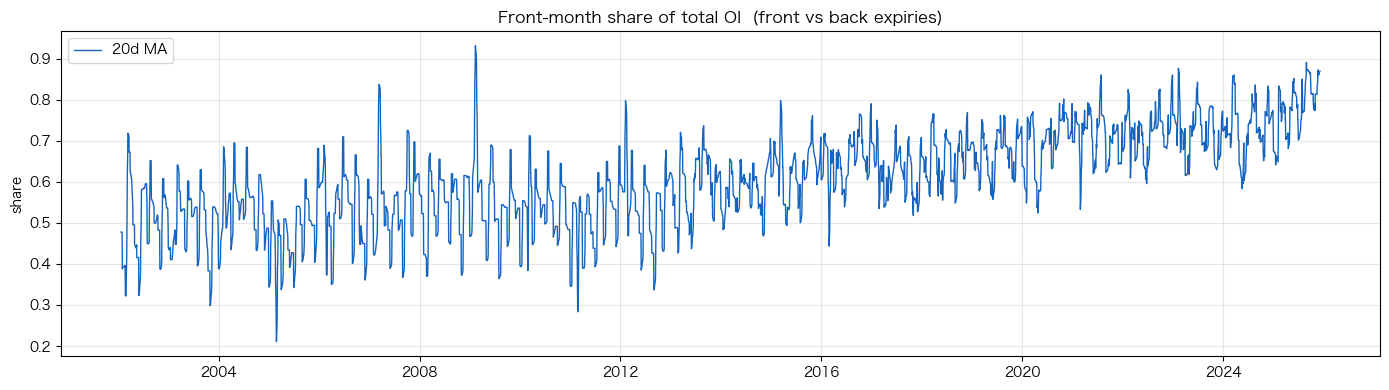


front-share stats (all history):
count    5879.000
mean        0.607
std         0.383
min         0.000
10%         0.000
50%         0.838
90%         0.958
max         0.993
Name: front_share, dtype: float64


In [6]:
# For each date, find the front-month code (earliest expiry_month ≥ this month).
# We then define "front" = expiries in the front expiry_month; "back" = everything else.
df_m = df[df["expiry"].notna()].copy()
df_m["cur_month"] = df_m["date"].dt.strftime("%Y%m")

def _is_front(row):
    return row["expiry_month"] == row["cur_month"]
df_m["is_front"] = df_m["expiry_month"] == df_m["cur_month"]

term = (df_m.groupby(["date", "is_front"])["oi"].sum().unstack(fill_value=0)
          .rename(columns={True: "oi_front", False: "oi_back"}))
term["oi_total"]      = term["oi_front"] + term["oi_back"]
term["front_share"]   = term["oi_front"] / term["oi_total"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(term.index, term["front_share"].rolling(20).mean(),
        color="#1565c0", lw=1.0, label="20d MA")
ax.set_title("Front-month share of total OI  (front vs back expiries)")
ax.set_ylabel("share"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nfront-share stats (all history):")
print(term["front_share"].describe(percentiles=[.1,.5,.9]).round(3))

## 6. Weekly vs monthly options mix

Weekly options were introduced late-2012 and now dominate volume. Track the fraction of daily volume that's in weekly contracts.

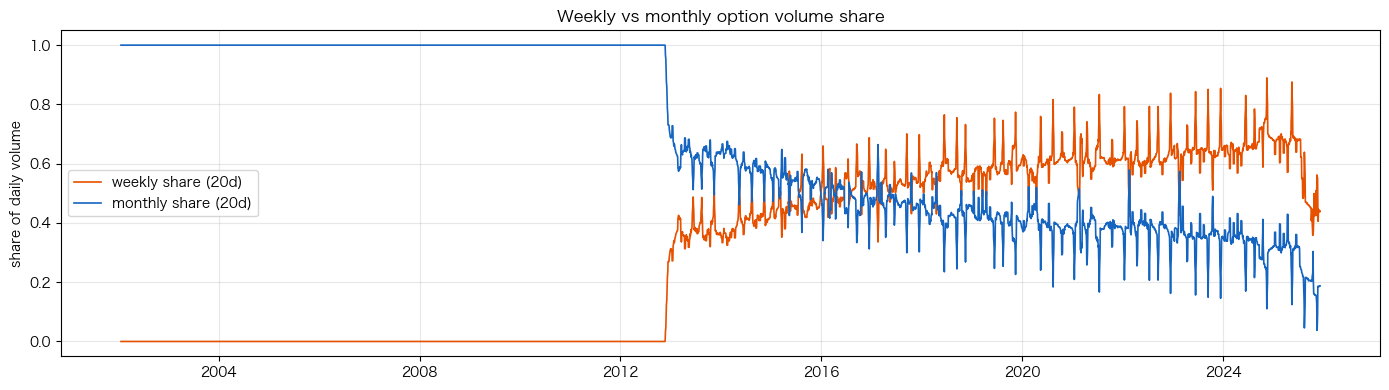

In [7]:
mix = (df.groupby(["date", "expiry_type"])["volume"].sum().unstack(fill_value=0))
mix["total"] = mix.sum(axis=1)
mix["weekly_share"]  = mix.get("weekly", 0)  / mix["total"].replace(0, np.nan)
mix["monthly_share"] = mix.get("monthly", 0) / mix["total"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mix.index, mix["weekly_share"].rolling(20).mean(),
        color="#e65100", lw=1.2, label="weekly share (20d)")
ax.plot(mix.index, mix["monthly_share"].rolling(20).mean(),
        color="#1565c0", lw=1.2, label="monthly share (20d)")
ax.set_title("Weekly vs monthly option volume share")
ax.set_ylabel("share of daily volume"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Strike moneyness distribution — where does volume live?

Heatmap of daily volume by log-moneyness bucket over time. High volume tends to cluster near ATM but you'll see wing activity spike during stress.

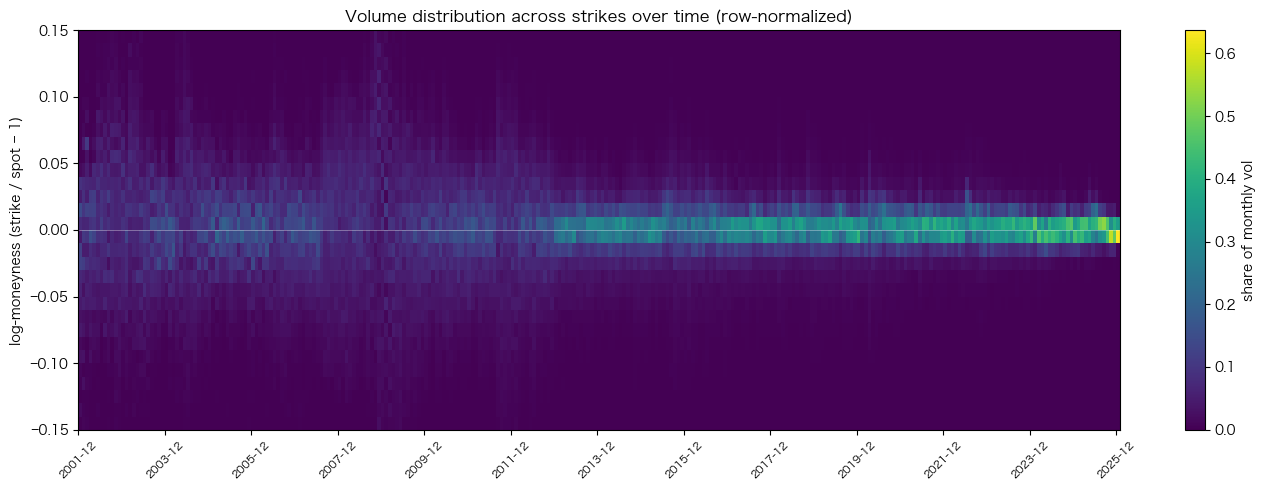

In [8]:
sub = df.dropna(subset=["underlying", "log_moneyness", "volume"]).copy()
# Restrict to near-ATM band for interpretability
sub = sub[sub["log_moneyness"].abs() < 0.15]
# Bin log-moneyness into 30 buckets
bins = np.linspace(-0.15, 0.15, 31)
sub["bin"] = pd.cut(sub["log_moneyness"], bins, include_lowest=True)
sub["year_month"] = sub["date"].dt.to_period("M").astype(str)

heat = sub.groupby(["year_month", "bin"])["volume"].sum().unstack(fill_value=0)
heat_frac = heat.div(heat.sum(axis=1), axis=0)     # normalize per row

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heat_frac.T.values, aspect="auto", cmap="viridis",
               origin="lower", interpolation="nearest",
               extent=[0, len(heat_frac), -0.15, 0.15])
step = max(len(heat_frac) // 12, 1)
ax.set_xticks(range(0, len(heat_frac), step))
ax.set_xticklabels(heat_frac.index[::step], rotation=45, fontsize=8)
ax.set_ylabel("log-moneyness (strike / spot − 1)")
ax.set_title("Volume distribution across strikes over time (row-normalized)")
ax.axhline(0, color="white", lw=0.6, alpha=0.4)
plt.colorbar(im, label="share of monthly vol", ax=ax)
plt.tight_layout(); plt.show()

## 8. ATM straddle premium — implied vol proxy

For each date, take the front-month call + put both nearest-to-ATM. Their settlement sum ≈ the market's expected magnitude of the move to expiry, i.e. an implied-vol proxy. Normalize by underlying to get a scale-free "vol premium %".

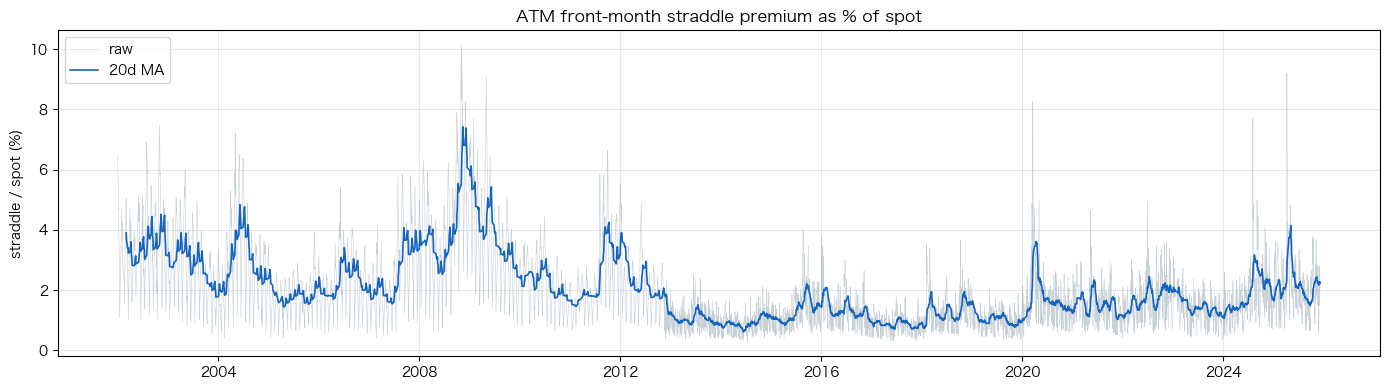

straddle_pct percentiles (all history):
count    4321.00
mean        1.96
std         1.32
min         0.30
10%         0.71
50%         1.59
90%         3.74
max        10.13
Name: straddle_pct, dtype: float64


In [9]:
# For each date, keep only front-month expiries (expiry_month == cur_month)
df_atm = df[(df["expiry_month"] == df["date"].dt.strftime("%Y%m")) &
            df["underlying"].notna() & df["settlement"].notna()].copy()

# Distance from ATM in absolute strike units
df_atm["dist"] = (df_atm["strike"] - df_atm["underlying"]).abs()

# Pick nearest-ATM call & put per date (there may be ties — take the min-dist single row)
atm = (df_atm.sort_values("dist")
             .drop_duplicates(["date", "side"], keep="first")
             .pivot(index="date", columns="side", values="settlement"))
atm = atm.dropna()
atm["straddle"] = atm["call"] + atm["put"]
atm = atm.join(spot, how="inner")
atm["straddle_pct"] = atm["straddle"] / atm["underlying"] * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(atm.index, atm["straddle_pct"], color="#90a4ae", lw=0.4, alpha=0.5, label="raw")
ax.plot(atm.index, atm["straddle_pct"].rolling(20).mean(),
        color="#1565c0", lw=1.2, label="20d MA")
ax.set_title("ATM front-month straddle premium as % of spot")
ax.set_ylabel("straddle / spot (%)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"straddle_pct percentiles (all history):")
print(atm["straddle_pct"].describe(percentiles=[.1,.5,.9]).round(2))

## 9. Put skew — crash-fear proxy

Compare OTM put and OTM call prices at roughly-symmetric moneyness (e.g. −5% put vs +5% call). A ratio > 1 means the OTM put is priced richer than the OTM call — the market is paying up for downside protection. Persistent skew above 1 is normal for equity indices ("crash-o-phobia"); spikes signal fear.

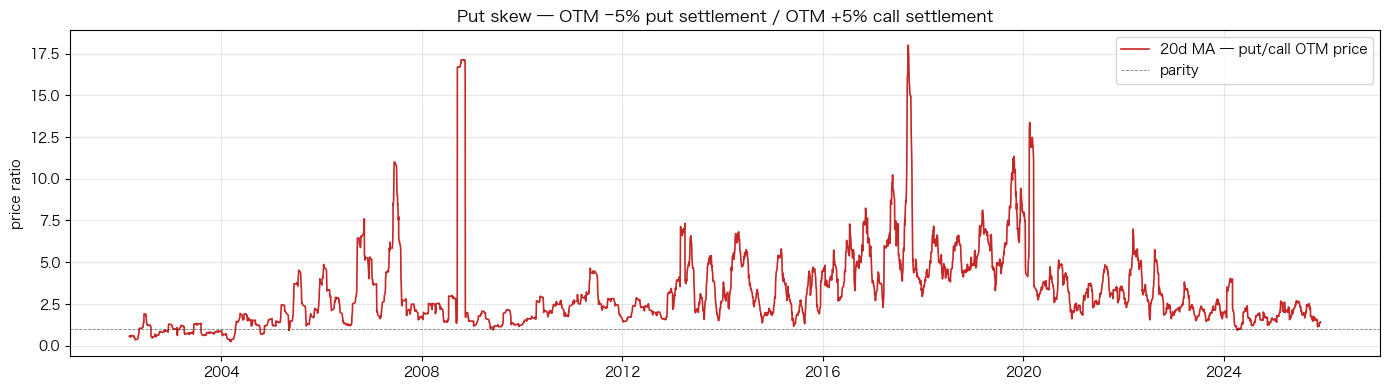

put/call OTM price ratio percentiles (last 252 days):
count    252.00
mean       1.91
std        1.60
min        0.12
10%        0.71
50%        1.55
90%        3.25
max       12.11
Name: put_over_call, dtype: float64


In [10]:
# For each date, find front-month OTM put at ~-5% moneyness and OTM call at ~+5%
df_sk = df[(df["expiry_month"] == df["date"].dt.strftime("%Y%m")) &
           df["underlying"].notna() & df["settlement"].notna() &
           (df["settlement"] > 0)].copy()
df_sk["target_moneyness"] = np.where(df_sk["side"] == "put", -0.05, 0.05)
df_sk["mn_dist"] = (df_sk["moneyness"] - df_sk["target_moneyness"]).abs()

otm = (df_sk.sort_values("mn_dist")
            .drop_duplicates(["date", "side"], keep="first")
            .pivot(index="date", columns="side", values="settlement"))
otm = otm.dropna()
otm["put_over_call"] = otm["put"] / otm["call"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(otm.index, otm["put_over_call"].rolling(20).mean(),
        color="#c62828", lw=1.2, label="20d MA — put/call OTM price")
ax.axhline(1.0, color="black", lw=0.6, ls="--", alpha=0.5, label="parity")
ax.set_title("Put skew — OTM −5% put settlement / OTM +5% call settlement")
ax.set_ylabel("price ratio"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"put/call OTM price ratio percentiles (last 252 days):")
print(otm["put_over_call"].tail(252).describe(percentiles=[.1,.5,.9]).round(2))

## 10. Signal sketches — feeding options data into `cta.Simulate`

Concrete daily signals derived from what we just built. Each returns a `pd.Series` you can plug into `cta.Simulate`, `cta.SimulateAll`, or the factor-zoo pipeline. All are PIT-safe because they're computed at end-of-day close and simulated with the standard `signal.shift(2)` inside `Simulate`.

### Signal candidates

* `pcr_vol_fade` — fade extreme daily PCR (contrarian on flow sentiment)
* `pcr_oi_fade` — same but on OI (slower)
* `straddle_pct_regime` — long when IV is unusually high (mean-reversion), short when low
* `put_skew_fade` — fade extreme put-skew days (crash-fear peaks → bounce)
* `front_share_extreme` — regime signal on near-term positioning concentration

Below builds the first three; the pattern extends trivially to the others.

pcr_vol_fade          n= 5870   range [-0.998, +1.000]
pcr_oi_fade           n= 5870   range [-0.996, +1.000]
straddle_regime       n= 4312   range [-0.977, +1.000]

=== pcr_vol_fade backtest ===


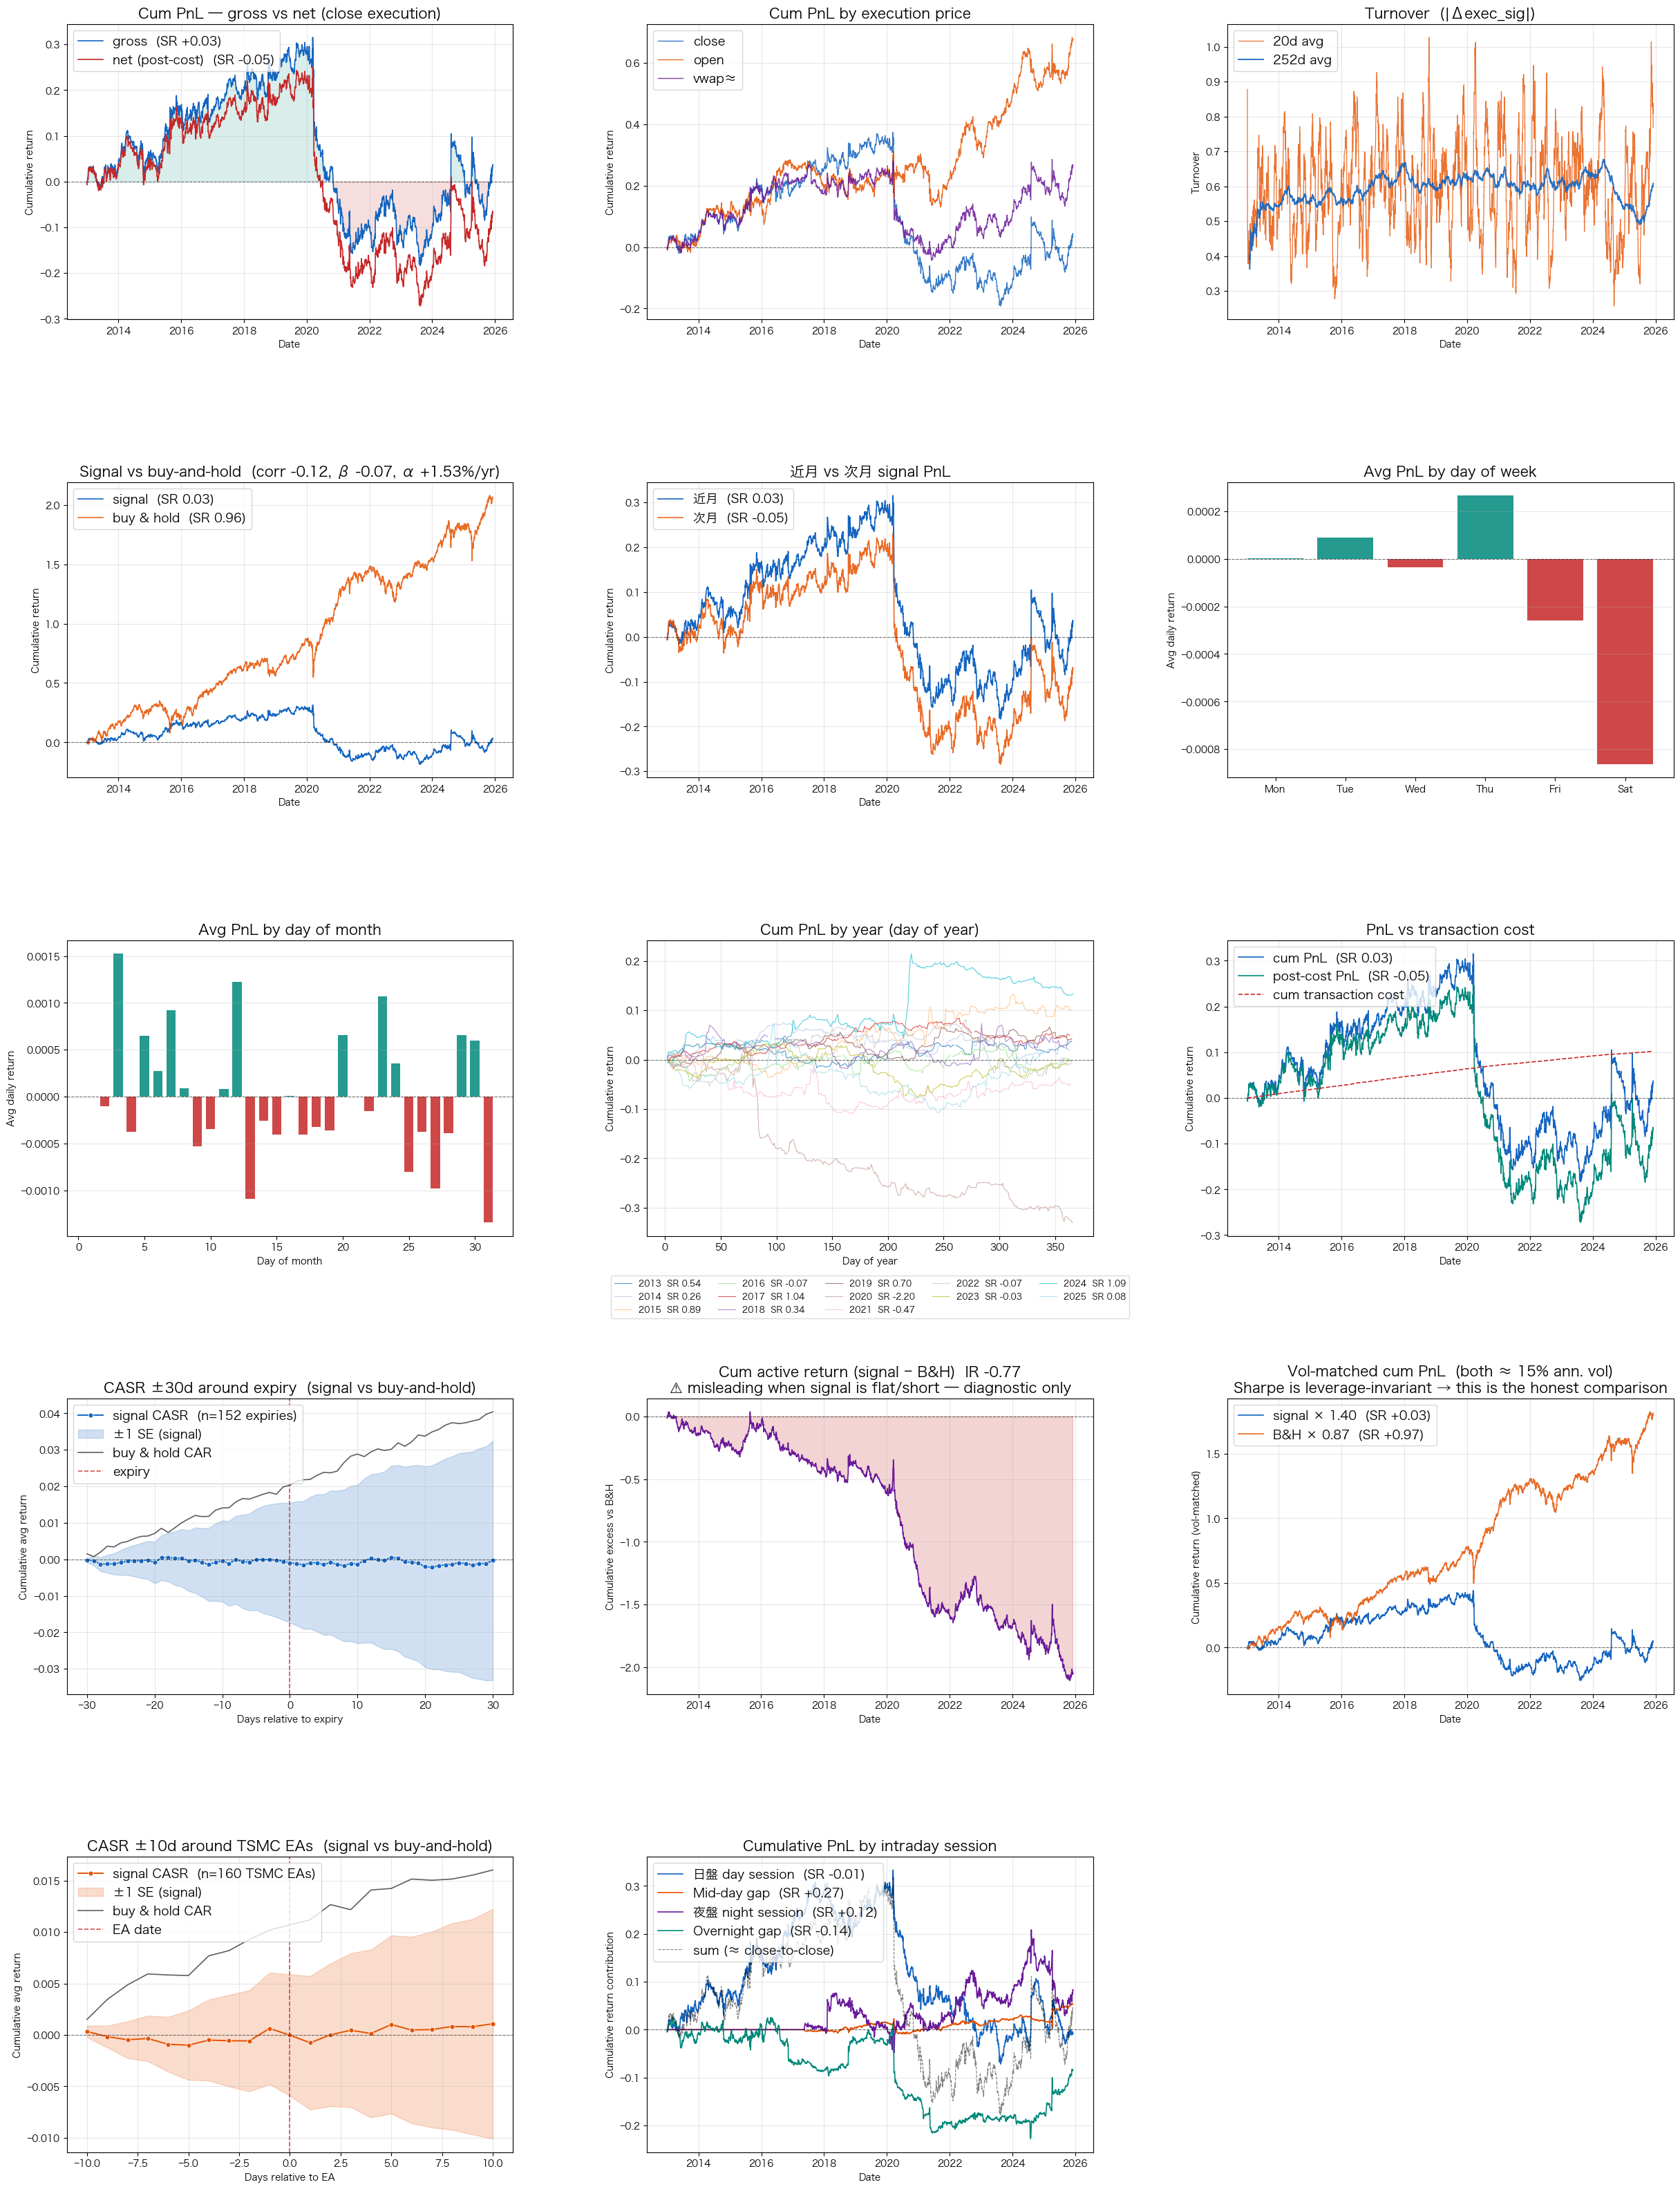

{'asset_obj': BaseAsset  MTX
   time_granularity : 1d
   bars             : 3,159
   start            : 2013-01-02
   end              : 2025-12-05
 
                open     high      low    close    volume  settlement       oi  \
 date                                                                            
 2013-01-02   7725.0   7804.0   7701.0   7775.0   52557.0      7773.0  20616.0   
 2013-01-03   7813.0   7835.0   7803.0   7825.0   34060.0      7824.0  20468.0   
 2013-01-04   7803.0   7809.0   7751.0   7775.0   40919.0      7775.0  19648.0   
 2013-01-07   7748.0   7775.0   7701.0   7742.0   47655.0      7741.0  20797.0   
 2013-01-08   7725.0   7747.0   7672.0   7710.0   55246.0      7709.0  21822.0   
 ...             ...      ...      ...      ...       ...         ...      ...   
 2025-12-01  27655.0  27674.0  27401.0  27402.0  116832.0     27406.0  35001.0   
 2025-12-02  27667.0  27789.0  27529.0  27561.0  110544.0     27559.0  34934.0   
 2025-12-03  27801.0  27888.0 

In [11]:
def _z(s, win=60):
    return (s - s.rolling(win, min_periods=10).mean()) / s.rolling(win, min_periods=10).std()
def _bounded(s):
    return np.tanh(s.replace([np.inf, -np.inf], np.nan))

cta.set_active_asset(ASSET)

# 1. Volume-PCR fade — high PCR = fear → contrarian long
sig_pcr_vol_fade = _bounded(_z(agg["pcr_vol"], 60)).rename("pcr_vol_fade")
# Sign: PCR up = signal up = long → we want fade, but leave un-flipped so
# the auto-flip in evaluate() picks the direction.

# 2. OI-PCR fade
sig_pcr_oi_fade = _bounded(_z(agg["pcr_oi"], 60)).rename("pcr_oi_fade")

# 3. Straddle-pct regime signal — long asset when IV is unusually high
sig_straddle_z = _bounded(_z(atm["straddle_pct"], 60)).rename("straddle_pct_regime")

for nm, s in [("pcr_vol_fade", sig_pcr_vol_fade),
              ("pcr_oi_fade",  sig_pcr_oi_fade),
              ("straddle_regime", sig_straddle_z)]:
    print(f"{nm:20s}  n={s.dropna().size:>5}   range [{s.min():+.3f}, {s.max():+.3f}]")

# Run one through cta.Simulate as a headline test
print("\n=== pcr_vol_fade backtest ===")
cta.set_date_range(start_date="2013-01-01", end_date=str(agg.index.max().date()))
cta.Simulate(sig_pcr_vol_fade, time_granularity="1d", normalize=False)

## Where to go from here

* Any of these daily signals plug into `three_majors_factor_search.ipynb`'s zoo — just add them to the `SIGNALS` dict before the `bulk_summary` sweep and they'll be ranked side-by-side with the three-majors factors.
* Cross-market factors: combine `pcr_oi` with `外資 net OI` — foreign long + high PCR = strong contrarian buy.
* Higher-order structure: **implied vol term structure** (short-dated vs long-dated straddle), **skew term structure**, **wing convexity** all computable from this same DataFrame with a bit more slicing.
* Extreme events: use `cta.InstRank(120, sig) > 0.98` to fire only on the top-2% strongest signal days.